# Screencast Inference Demo

This notebook is the lightweight demo for the code screencast. It does not run shell scripts and does not start training. It directly imports the project code, loads four fixed Facebook Hateful Memes test examples stored under `notebooks/demo_samples/`, loads the selected trained checkpoint, and shows image, text, semantic cues, ground truth, and prediction for each sample.

The real model used here is:

`outputs/runai_qwen_vl_fields_image_resproj1024_rkc_lr5e5/best_clf_auroc.pt`

If that checkpoint is unavailable, the code falls back to `best_model.pt` in the same directory.


In [1]:
from pathlib import Path
import json
import os
import sys

# Locate repository root from this notebook or from the current working directory.
cwd = Path.cwd().resolve()
for candidate in [cwd, *cwd.parents]:
    if (candidate / "src" / "semantic_rahmd").exists():
        REPO = candidate
        break
else:
    raise RuntimeError("Could not locate repository root containing src/semantic_rahmd")

os.chdir(REPO)
SRC = REPO / "src"
VENDOR = REPO / "vendor" / "python"

# Put repo-local packages first; this avoids older course-image packages shadowing installed demo deps.
for path in [str(SRC), str(VENDOR)]:
    while path in sys.path:
        sys.path.remove(path)
if VENDOR.exists():
    sys.path.insert(0, str(VENDOR))
sys.path.insert(0, str(SRC))

print("repo:", REPO)
print("src:", SRC)
print("vendor:", VENDOR, "exists=", VENDOR.exists())

import semantic_rahmd
print("semantic_rahmd import: OK")

try:
    import sentence_transformers
    print("sentence_transformers:", sentence_transformers.__version__, sentence_transformers.__file__)
except Exception as exc:
    print("sentence_transformers import failed:", exc)
    print("Run this once in a terminal, then restart the RunAI notebook job:")
    print("bash scripts/runai_install_semantic_deps.sh")


repo: /scratch/hateful_meme_semantic_retrieval
src: /scratch/hateful_meme_semantic_retrieval/src
vendor: /scratch/hateful_meme_semantic_retrieval/vendor/python exists= True
semantic_rahmd import: OK


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sentence_transformers: 5.4.0 /scratch/hateful_meme_semantic_retrieval/vendor/python/sentence_transformers/__init__.py


## 1. Load Four Test Demo Samples

These are real test-set examples copied into the notebook folder for a fast, stable screencast. Each sample includes the image, meme text, ground-truth label, and precomputed semantic cues from the frozen VLM cue generator.


In [2]:
from PIL import Image
from IPython.display import display

SAMPLES_JSON = REPO / "notebooks" / "demo_samples" / "samples.json"
with SAMPLES_JSON.open(encoding="utf-8") as f:
    samples = json.load(f)

print("samples:", len(samples))
for sample in samples:
    image_path = REPO / "notebooks" / sample["image_path"]
    sample["_image_abs"] = str(image_path)
    print(sample["id"], "split=", sample["split"], "label=", sample["label"], "image=", image_path.name)


samples: 4
16395 split= test_seen label= 1 image= test_seen_16395.png
37405 split= test_seen label= 1 image= test_seen_37405.png
70691 split= test_seen label= 0 image= test_seen_70691.png
89263 split= test_seen label= 0 image= test_seen_89263.png


## 2. Load the Real Model Checkpoint

The checkpoint comes from `runai_qwen_vl_fields_image_resproj1024_rkc_lr5e5`. The notebook uses `best_clf_auroc.pt` for direct prediction display because it is selected by classification AUROC. If it is missing, it falls back to `best_model.pt`.


In [3]:
import torch
from semantic_rahmd.infer import FIELD_NAMES, checkpoint_args, item_to_fields
from semantic_rahmd.model import build_model

OUTPUT_DIR = REPO / "outputs" / "runai_qwen_vl_fields_image_resproj1024_rkc_lr5e5"
CHECKPOINT = OUTPUT_DIR / "best_clf_auroc.pt"
if not CHECKPOINT.exists():
    CHECKPOINT = OUTPUT_DIR / "best_model.pt"
if not CHECKPOINT.exists():
    raise FileNotFoundError(f"Could not find checkpoint under {OUTPUT_DIR}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
print("checkpoint:", CHECKPOINT)

state = torch.load(CHECKPOINT, map_location=DEVICE)
model_args = checkpoint_args(state.get("args", {}))

# Compatibility: ResProj checkpoints were trained before this option was named in args.
if any("aggregator.input_residual" in key for key in state["model"].keys()):
    model_args.use_residual_projection = True

print("encoder_backend:", model_args.encoder_backend)
print("llm_model:", model_args.llm_model)
print("proj_dim:", model_args.proj_dim)
print("use_residual_projection:", getattr(model_args, "use_residual_projection", False))

model = build_model(model_args).to(DEVICE)
model.load_state_dict(state["model"])
model.eval()
print("model loaded")


device: cuda
checkpoint: /scratch/hateful_meme_semantic_retrieval/outputs/runai_qwen_vl_fields_image_resproj1024_rkc_lr5e5/best_clf_auroc.pt


The `tokenizer_kwargs` argument was renamed and is now deprecated. Please use `processor_kwargs` instead.


encoder_backend: st_image
llm_model: Qwen/Qwen3-VL-Embedding-8B
proj_dim: 1024
use_residual_projection: True


Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████| 749/749 [00:00<00:00, 3611.99it/s]
Default prompt name is set to 'default'. This prompt will be applied to all inference calls, except if a `prompt` or `prompt_name` parameter is provided.
/scratch/hateful_meme_semantic_retrieval/src/semantic_rahmd/model.py:142: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  dim = self.model.get_sentence_embedding_dimension()
/scratch/hateful_meme_semantic_retrieval/src/semantic_rahmd/model.py:268: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


model loaded


## 3. Run Inference and Display Results

For each sample below, the model receives:

1. raw meme image;
2. original meme text;
3. seven semantic cue fields.

The output shows ground truth and prediction, plus the aggregator attention weights over text, cue fields, and image.


ID: 16395 | split: test_seen | ground truth: 1 | prediction: 1 | P(hateful): 0.996


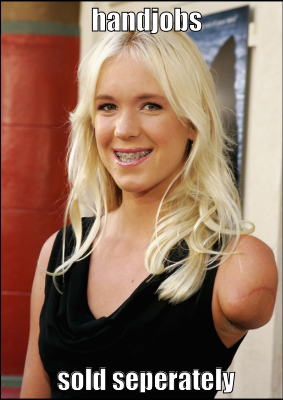

Text:
handjobs sold seperately

Semantic cues:
- GlobalDescription: A woman with blonde hair and braces is shown in a black top, with text overlay reading "handjobs" above her and "sold separately" below her.
- TargetCandidateType: person
- TargetCandidate: the woman in the image
- ProtectedTargetPossible: no
- ProtectedTargetType: none
- RelationOrAction: text overlay implying a commercial or transactional relationship
- SafetyReasonCode: only_animal_object_place

Field weights:
- Text: 0.000
- GlobalDescription: 0.000
- TargetCandidateType: 0.000
- TargetCandidate: 0.000
- ProtectedTargetPossible: 0.000
- ProtectedTargetType: 0.000
- RelationOrAction: 0.000
- SafetyReasonCode: 0.000
- Image: 1.000
ID: 37405 | split: test_seen | ground truth: 1 | prediction: 0 | P(hateful): 0.003


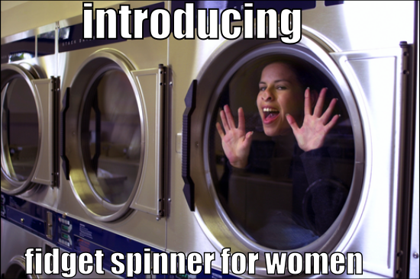

Text:
introducing fidget spinner for women

Semantic cues:
- GlobalDescription: A woman is visible inside a front-loading washing machine, waving with both hands, with text overlay reading "introducing fidget spinner for women".
- TargetCandidateType: person
- TargetCandidate: women
- ProtectedTargetPossible: yes
- ProtectedTargetType: sex
- RelationOrAction: woman inside washing machine waving
- SafetyReasonCode: explicit_person_group

Field weights:
- Text: 0.047
- GlobalDescription: 0.056
- TargetCandidateType: 0.000
- TargetCandidate: 0.000
- ProtectedTargetPossible: 0.000
- ProtectedTargetType: 0.000
- RelationOrAction: 0.000
- SafetyReasonCode: 0.000
- Image: 0.897
ID: 70691 | split: test_seen | ground truth: 0 | prediction: 0 | P(hateful): 0.005


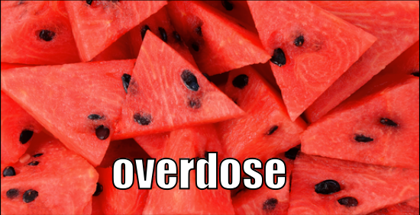

Text:
overdose

Semantic cues:
- GlobalDescription: The image shows sliced watermelon with the word "overdose" superimposed.
- TargetCandidateType: none
- TargetCandidate: none
- ProtectedTargetPossible: no
- ProtectedTargetType: none
- RelationOrAction: none
- SafetyReasonCode: only_animal_object_place

Field weights:
- Text: 0.002
- GlobalDescription: 0.055
- TargetCandidateType: 0.065
- TargetCandidate: 0.065
- ProtectedTargetPossible: 0.132
- ProtectedTargetType: 0.065
- RelationOrAction: 0.065
- SafetyReasonCode: 0.053
- Image: 0.497
ID: 89263 | split: test_seen | ground truth: 0 | prediction: 0 | P(hateful): 0.003


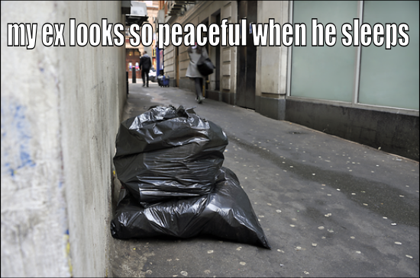

Text:
my ex looks so peaceful when he sleeps

Semantic cues:
- GlobalDescription: A pile of black trash bags on a sidewalk is juxtaposed with text stating "my ex looks so peaceful when he sleeps."
- TargetCandidateType: person
- TargetCandidate: ex
- ProtectedTargetPossible: yes
- ProtectedTargetType: none
- RelationOrAction: comparison
- SafetyReasonCode: explicit_person_group

Field weights:
- Text: 0.014
- GlobalDescription: 0.965
- TargetCandidateType: 0.000
- TargetCandidate: 0.000
- ProtectedTargetPossible: 0.000
- ProtectedTargetType: 0.014
- RelationOrAction: 0.005
- SafetyReasonCode: 0.000
- Image: 0.001


In [4]:
from semantic_rahmd.data import parse_semantic_cues

fields_batch = [item_to_fields(sample) for sample in samples]
images = [Image.open(sample["_image_abs"]).convert("RGB") for sample in samples]

with torch.no_grad():
    outputs = model(fields_batch, images=images)
    probabilities = torch.sigmoid(outputs["logits"]).detach().cpu().tolist()
    weights = outputs["field_weights"].detach().cpu().tolist()

names = [*FIELD_NAMES, "Image"]

for sample, image, prob, sample_weights in zip(samples, images, probabilities, weights):
    pred = int(prob >= 0.5)
    parsed = parse_semantic_cues(sample["semantic_cues"])
    print("=" * 90)
    print(f"ID: {sample['id']} | split: {sample['split']} | ground truth: {sample['label']} | prediction: {pred} | P(hateful): {prob:.3f}")
    display(image.resize((min(420, image.width), int(image.height * min(420, image.width) / image.width))))
    print("Text:")
    print(sample["text"])
    print()
    print("Semantic cues:")
    for key, value in parsed.items():
        print(f"- {key}: {value}")
    print()
    print("Field weights:")
    for name, value in zip(names, sample_weights):
        print(f"- {name}: {value:.3f}")


## What to Say in the Screencast

- The four samples are parsed from the local test-set cache and copied into `notebooks/demo_samples/` for a stable demo.
- The notebook directly imports the submitted source code under `src/semantic_rahmd`.
- The final model embeds image, meme text, and semantic cues with frozen Qwen3-VL-Embedding-8B, then aggregates them with the Transformer field aggregator.
- The output displays the visible input, semantic units, ground truth, prediction, and attention weights.
